In [ ]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Final_Dataset.xlsx to Final_Dataset.xlsx


In [ ]:
# Load the cleaned dataset
df_cleaned = pd.read_excel('Final_Dataset.xlsx', sheet_name='Model_Dataset', skiprows=[0, 2])
df_cleaned.head()

,Date,BNB-USD,BTC-USD,ETH-USD,USDT-USD,XRP-USD,ADA-USD,BITG-USD,MIOTA-USD,XNO-USD,POWR-USD,Power,Ground Transport,Residential,Domestic Aviation,International Aviation
0,2019-01-03,-0.283723,-0.146478,-0.218059,-0.242175,-0.213296,-0.133797,0.272976,-0.350994,-0.212519,-0.541858,0.017161,0.100704,-0.013013,0.037922,0.026545
1,2019-01-04,0.250258,0.067790,0.155431,0.110796,0.026443,-0.276461,-0.199125,0.001564,0.155184,-0.798119,0.015954,0.002050,-0.008488,-0.013425,0.013110
2,2019-01-05,0.034520,0.058029,0.065619,0.024849,0.003227,0.448817,-1.063302,-0.364719,0.394051,0.533827,-0.031367,-0.072048,-0.042761,-0.084376,0.028308
3,2019-01-06,0.314991,0.085648,-0.032553,0.056192,0.085732,0.716078,-0.655398,0.427898,0.268170,1.404755,-0.020110,-0.145075,-0.015340,0.001235,0.016680
4,2019-01-07,-0.092145,-0.068087,-0.175156,-0.115993,0.013049,-0.117139,0.675955,-0.436056,-0.465483,-1.400369,0.045889,0.199612,0.012749,0.042424,-0.069635


In [ ]:
df_cleaned.isna()

,Date,BNB-USD,BTC-USD,ETH-USD,USDT-USD,XRP-USD,ADA-USD,BITG-USD,MIOTA-USD,XNO-USD,POWR-USD,Power,Ground Transport,Residential,Domestic Aviation,International Aviation
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1544,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1545,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1546,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1547,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_cleaned=df_cleaned[['Date', 'ADA-USD', 'BITG-USD','MIOTA-USD', 'XNO-USD', 'POWR-USD', 'Power']]
df_cleaned.isnull().sum()


,0
Date,0
ADA-USD,0
BITG-USD,34
MIOTA-USD,0
XNO-USD,5
POWR-USD,0
Power,0


In [ ]:
df_cleaned.dropna(inplace=True)

In [ ]:
#df_cleaned.head()
df_cleaned.info()
df_cleaned.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1510 entries, 0 to 1548
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1510 non-null   datetime64[ns]
 1   ADA-USD    1510 non-null   float64       
 2   BITG-USD   1510 non-null   float64       
 3   MIOTA-USD  1510 non-null   float64       
 4   XNO-USD    1510 non-null   float64       
 5   POWR-USD   1510 non-null   float64       
 6   Power      1510 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 94.4 KB


(1510, 7)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Step 1: Create lagged versions of the 'Power' column
df_cleaned['Power_Lag1'] = df_cleaned['Power'].shift(1)
df_cleaned['Power_Lag2'] = df_cleaned['Power'].shift(2)

# Step 2: Add lagged features to exogenous variables
#exog_variables = pd.concat([exog_variables, df_cleaned[['Power_Lag1', 'Power_Lag2']]], axis=1)

# Step 3: Fill any missing values (due to the lag operation)
#exog_variables = exog_variables.fillna(method='ffill')
df_cleaned.dropna(inplace=True)
df_cleaned.shape

(1508, 9)

In [ ]:
warnings.filterwarnings("ignore")

# Step 2: Handle missing values in the exogenous variables
exog_variables = df_cleaned[['ADA-USD', 'BITG-USD','MIOTA-USD', 'XNO-USD', 'POWR-USD', 'Power_Lag1', 'Power_Lag2']]

# Check for missing or infinite values
exog_variables = exog_variables.replace([np.inf, -np.inf], np.nan)

# Fill missing values using forward-fill method
exog_variables = exog_variables.fillna(method='ffill')

# Output variable (ensure no missing values)
output_variable = df_cleaned['Power'].fillna(method='ffill')

# Ensure exogenous variables are numeric
exog_variables = exog_variables.apply(pd.to_numeric)

# Scale the exogenous variables
scaler = StandardScaler()
scaled_exog_variables = pd.DataFrame(scaler.fit_transform(exog_variables), index=exog_variables.index, columns=exog_variables.columns)


In [ ]:
# Step 3: Split the data into training and testing sets
train_size = int(len(df_cleaned) * 0.85)
train_exog = scaled_exog_variables[:train_size]
train_output = output_variable[:train_size]
test_exog = scaled_exog_variables[train_size:]
test_output = output_variable[train_size:]

In [ ]:
# Step 4: Ensure indices are aligned
train_exog = train_exog.loc[train_output.index]
test_exog = test_exog.loc[test_output.index]
train_exog.isna().sum()

,0
ADA-USD,0
BITG-USD,0
MIOTA-USD,0
XNO-USD,0
POWR-USD,0
Power_Lag1,0
Power_Lag2,0


In [ ]:
test_exog.isna().sum()

,0
ADA-USD,0
BITG-USD,0
MIOTA-USD,0
XNO-USD,0
POWR-USD,0
Power_Lag1,0
Power_Lag2,0


In [ ]:
# Debugging: Check shapes and index alignment
print(f"Shape of train_exog: {train_exog.shape}")
print(f"Shape of train_output: {train_output.shape}")
print(f"Index alignment check: {train_exog.index.equals(train_output.index)}")
print(f"Shape of test_exog: {test_exog.shape}")
print(f"Shape of test_output: {test_output.shape}")

Shape of train_exog: (1281, 7)
Shape of train_output: (1281,)
Index alignment check: True
Shape of test_exog: (227, 7)
Shape of test_output: (227,)


In [ ]:
# Fit the ARIMAX model
import warnings

warnings.filterwarnings("ignore")

model = SARIMAX(train_output, exog=train_exog, order=(1, 1, 2), seasonal_order=(0, 0, 1, 12), maxiter=500)
model_fit = model.fit(disp=False)


In [ ]:
# Make predictions on the test data
predictions = model_fit.forecast(steps=len(test_output), exog=test_exog)

In [ ]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

warnings.filterwarnings("ignore")

# Define the parameter ranges for tuning
p = range(0, 3)  # Non-seasonal AR terms
d = range(0, 2)  # Differencing terms
q = range(0, 3)  # Non-seasonal MA terms
P = range(0, 3)  # Seasonal AR terms
D = range(0, 2)  # Seasonal differencing terms
Q = range(0, 3)  # Seasonal MA terms
s = [12]         # Seasonality period (assuming monthly data)

best_mape = float("inf")
best_params = None

# Grid search over parameter combinations
for i in p:
    for j in d:
        for k in q:
            for P_season in P:
                for D_season in D:
                    for Q_season in Q:
                        try:
                            model = SARIMAX(train_output, exog=train_exog, order=(i, j, k),
                                            seasonal_order=(P_season, D_season, Q_season, s[0]), maxiter=500)
                            model_fit = model.fit(disp=False)
                            predictions = model_fit.forecast(steps=len(test_output), exog=test_exog)

                            # Calculate MAPE for model evaluation
                            mape = mean_absolute_percentage_error(test_output, predictions)

                            if mape < best_mape:
                                best_mape = mape
                                best_params = ((i, j, k), (P_season, D_season, Q_season, s[0]))
                                print(f"New best MAPE: {mape} with params: order={(i, j, k)}, seasonal_order={(P_season, D_season, Q_season, s[0])}")
                        except Exception as e:
                            continue

print(f"Best MAPE: {best_mape} with params: {best_params}")

In [ ]:
# Calculate performance metrics
mse = mean_squared_error(test_output, predictions)
mae = mean_absolute_error(test_output, predictions)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test_output, predictions)
r2 = r2_score(test_output, predictions)


In [ ]:
# Display performance metrics
print("Model Validation Metrics:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")
print(f"R-Squared (R²): {r2}")

Model Validation Metrics:
Mean Squared Error (MSE): 0.000722590454123461
Mean Absolute Error (MAE): 0.0205522328664713
Root Mean Squared Error (RMSE): 0.026881042653205643
Mean Absolute Percentage Error (MAPE): 1.369098144398987
R-Squared (R²): 0.18786700160627812


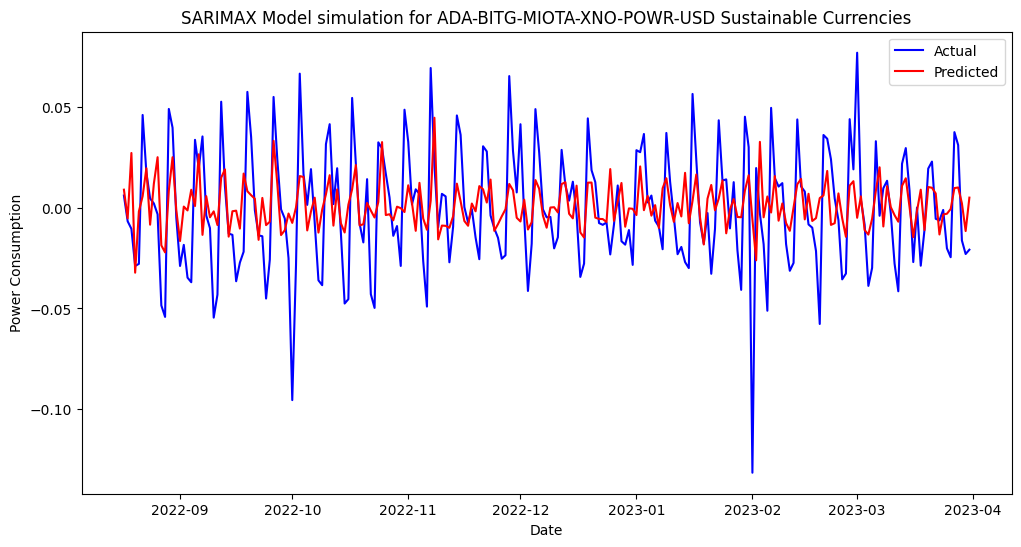

In [ ]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned['Date'][1281:1508], test_output, label='Actual', color='blue')
plt.plot(df_cleaned['Date'][1281:1508], predictions, label='Predicted', color='red')
plt.title('SARIMAX Model simulation for ADA-BITG-MIOTA-XNO-POWR-USD Sustainable Currencies')
plt.xlabel('Date')
plt.ylabel('Power Consumption')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px

# Ensure the 'test_output' and 'predictions' are numpy arrays
test_output = np.array(test_output)
predictions = np.array(predictions)
# Ensure both arrays have the same length
min_length = min(len(test_output), len(predictions))
test_output = test_output[:min_length]
predictions = predictions[:min_length]
dates = df_cleaned['Date'][1281:1281+min_length]

# Step 1: Combine the actual and predicted values into a single DataFrame
df_results = pd.DataFrame({
    'Date': dates,
    'Actual': test_output,
    'Predicted': predictions
})

# Step 2: Create the line plot with Plotly Express
fig = px.line(df_results,
              x='Date',
              y=['Actual', 'Predicted'],  # Plot both Actual and Predicted
              labels={'value': 'Power Consumption', 'variable': 'Legend'},
              title="SARIMAX-MISO model simulation for ADA-BITG-MIOTA-XNO-POWR-USD Sustainable Currencies")

# Step 3: Show the plot
fig.show()



In [ ]:
import plotly.graph_objects as go

# Create a DataFrame with Actual and Predicted values
df_results = pd.DataFrame({
    'Date': df_cleaned['Date'][1281:1508],
    'Actual': test_output,
    'Predicted': predictions
})

# Initialize a figure
fig = go.Figure()

# Add trace for Actual values (Expectation)
fig.add_trace(go.Scatter(
    x=df_results['Date'],
    y=df_results['Actual'],
    name="Actual",
    mode="lines",
    line=dict(color='blue')
))

# Add trace for Predicted values (Prediction)
fig.add_trace(go.Scatter(
    x=df_results['Date'],
    y=df_results['Predicted'],
    name="Predicted",
    mode="lines",
    line=dict(color='green')
))

# Customize layout
fig.update_layout(
    title="SARIMAX-MISO model simulation for ADA-BITG-MIOTA-XNO-POWR-USD Sustainable Currencies",
    xaxis=dict(title="Date"),
    yaxis=dict(title="Power Consumption"),
    hovermode="x unified",  # Show a vertical line on hover across both traces
)

# Add data points on hover
fig.update_traces(hovertemplate="Date: %{x}<br>Value: %{y}")

# Add range slider for Date
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

# Show the plot
fig.show()
